# 1. Environment Setup and Library Imports

In [1]:
!pip install thop -q

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from thop import profile
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score, roc_curve

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classes = ['AD', 'CN', 'MCI']
label_map = {cls: i for i, cls in enumerate(classes)}

# 2. Dataset Loading and Stratified Splitting (50:50 Ratio)

In [2]:
base_path = '/kaggle/input/datasets/jubayerhasan755/notebook1-dataset/alzheimer'
all_paths = []
all_labels = []

for split_folder in ['train', 'test']:
    for cls in classes:
        folder_path = os.path.join(base_path, split_folder, cls)
        if os.path.exists(folder_path):
            for img in os.listdir(folder_path):
                if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                    all_paths.append(os.path.join(folder_path, img))
                    all_labels.append(label_map[cls])

train_files, test_files, train_labels, test_labels = train_test_split(
    all_paths, all_labels, train_size=0.5, stratify=all_labels, random_state=42
)

t_files, v_files, t_labels, v_labels = train_test_split(
    train_files, train_labels, test_size=0.1, stratify=train_labels, random_state=42
)

class AlzheimerDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(AlzheimerDataset(t_files, t_labels, transform), batch_size=32, shuffle=True)
val_loader = DataLoader(AlzheimerDataset(v_files, v_labels, transform), batch_size=32)
test_loader = DataLoader(AlzheimerDataset(test_files, test_labels, transform), batch_size=32)

print(f"Total Images: {len(all_paths)}")
print(f"Training: {len(t_files)}, Validation: {len(v_files)}, Testing: {len(test_files)}")

Total Images: 5154
Training: 2319, Validation: 258, Testing: 2577


# 3. Computational Complexity: GFLOPs per Inference (Input Size: 224x224)

In [3]:
model = models.resnet50(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, len(classes))
model = model.to(device)

dummy_in = torch.randn(1, 3, 224, 224).to(device)
macs, params = profile(model, inputs=(dummy_in, ), verbose=False)
gflops = (macs * 2) / 1e9

print(f"Fixed Input Size: 224x224")
print(f"GFLOPs: {gflops:.4f}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s] 


Fixed Input Size: 224x224
GFLOPs: 8.2634


# 4. Model Training and Training Wall-clock Time Tracking

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

start_train = time.time()
for epoch in range(50):
    model.train()
    running_loss = 0.0
    for imgs, labs in train_loader:
        imgs, labs = imgs.to(device), labs.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, labs in val_loader:
            imgs, labs = imgs.to(device), labs.to(device)
            val_loss += criterion(model(imgs), labs).item()
    
    print(f"Epoch [{epoch+1}/50] | Train Loss: {running_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

train_wall_time = time.time() - start_train
print(f"Total Training Time: {train_wall_time:.2f} s")

Epoch [1/50] | Train Loss: 0.4301 | Val Loss: 0.1626
Epoch [2/50] | Train Loss: 0.0849 | Val Loss: 0.0908
Epoch [3/50] | Train Loss: 0.0315 | Val Loss: 0.1535
Epoch [4/50] | Train Loss: 0.0398 | Val Loss: 0.0934
Epoch [5/50] | Train Loss: 0.0406 | Val Loss: 0.0459
Epoch [6/50] | Train Loss: 0.0242 | Val Loss: 0.0500
Epoch [7/50] | Train Loss: 0.0117 | Val Loss: 0.0258
Epoch [8/50] | Train Loss: 0.0052 | Val Loss: 0.0149
Epoch [9/50] | Train Loss: 0.0048 | Val Loss: 0.0442
Epoch [10/50] | Train Loss: 0.0010 | Val Loss: 0.0205
Epoch [11/50] | Train Loss: 0.0004 | Val Loss: 0.0238
Epoch [12/50] | Train Loss: 0.0013 | Val Loss: 0.0357
Epoch [13/50] | Train Loss: 0.0012 | Val Loss: 0.0320
Epoch [14/50] | Train Loss: 0.0015 | Val Loss: 0.0089
Epoch [15/50] | Train Loss: 0.0066 | Val Loss: 0.2187
Epoch [16/50] | Train Loss: 0.0792 | Val Loss: 0.6153
Epoch [17/50] | Train Loss: 0.0811 | Val Loss: 0.3230
Epoch [18/50] | Train Loss: 0.0267 | Val Loss: 0.0097
Epoch [19/50] | Train Loss: 0.0103 | 

# 5. Global Performance Metrics and Testing Wall-clock Time

In [5]:
model.eval()
y_true, y_pred, y_prob = [], [], []
start_test = time.time()
with torch.no_grad():
    for imgs, labs in test_loader:
        imgs, labs = imgs.to(device), labs.to(device)
        out = model(imgs)
        y_prob.extend(torch.softmax(out, dim=1).cpu().numpy())
        y_pred.extend(torch.argmax(out, dim=1).cpu().numpy())
        y_true.extend(labs.cpu().numpy())
test_wall_time = time.time() - start_test

acc = accuracy_score(y_true, y_pred)
p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
auc = roc_auc_score(y_true, y_prob, multi_class='ovr')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {p:.4f}")
print(f"Recall: {r:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {auc:.4f}")
print(f"Testing Wall-clock Time: {test_wall_time:.2f} s")

Accuracy: 0.9957
Precision: 0.9957
Recall: 0.9957
F1-score: 0.9957
ROC-AUC: 1.0000
Testing Wall-clock Time: 31.48 s


# 6. Per-class Accuracy and Confusion Matrix Analysis

Accuracy for AD: 0.9982
Accuracy for CN: 0.9917
Accuracy for MCI: 0.9969


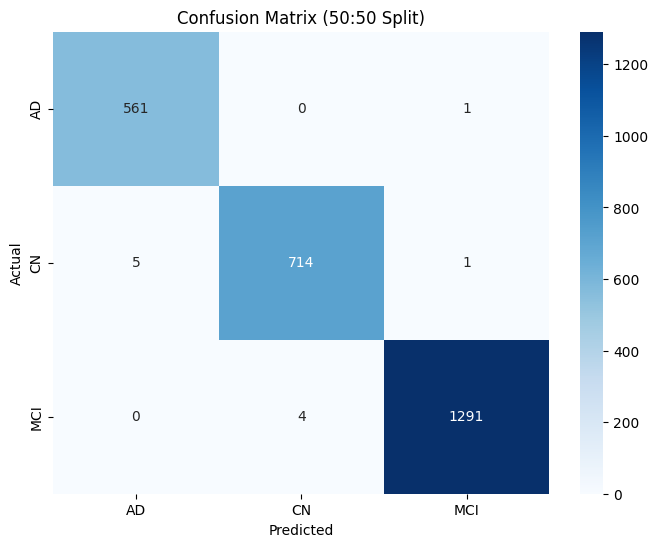

In [6]:
cm = confusion_matrix(y_true, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

for i, cls in enumerate(classes):
    print(f"Accuracy for {cls}: {per_class_acc[i]:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (50:50 Split)')
plt.show()

# 7. ROC Curves Visualization and Failure Mode Analysis

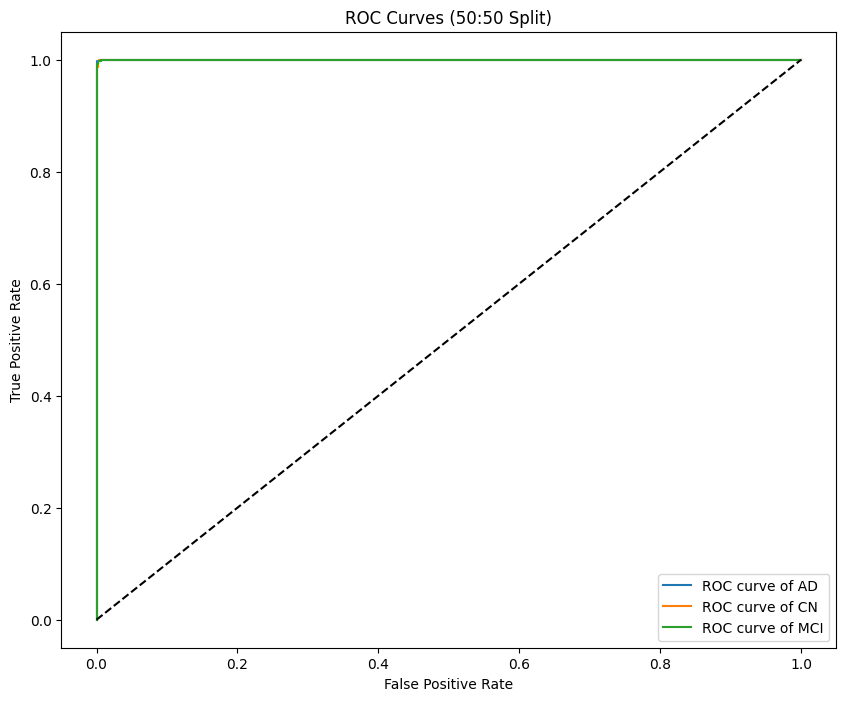

In [7]:
plt.figure(figsize=(10, 8))
y_prob_np = np.array(y_prob)
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_true, y_prob_np[:, i], pos_label=i)
    plt.plot(fpr, tpr, label=f'ROC curve of {classes[i]}')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (50:50 Split)')
plt.legend()
plt.show()